# 06 — Uncertainty Quantification v2: ECGUNet v14 vs TCN v6
# Both models — PTB-XL ECG Forecasting (4.9 s → 4.9 s)
# Run locally in Jupyter.  Expects checkpoints in ../reports/checkpoints/
#   CNN:  ECG_CNN_v14_best.pt   (from Google Account A — CNN-LSTM training)
#   TCN:  TCN_v6_best.pt        (from Google Account B — TCN training)


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 120, 'savefig.dpi': 150,
})
print(f"Device: {DEVICE}")
print("✅ Imports ready")


Device: cpu
✅ Imports ready


In [2]:
# CELL 2 — PATHS & CONFIG
# ── Local folder layout ───────────────────────────────────────────────
#  project_root/
#    data/processed/        ← X_test.npy, y_test.npy, config.pkl
#    reports/
#      checkpoints/         ← ECG_CNN_v14_best.pt  +  TCN_v6_best.pt
#      figures/uncertainty/ ← output PNGs land here
#
# Download from Google Drive:
#   Account A  →  reports/checkpoints/ECG_CNN_v14_best.pt
#   Account B  →  reports/checkpoints/TCN_v6_best.pt
# ─────────────────────────────────────────────────────────────────────

SAVE_DIR = os.path.join('..', 'data', 'processed')
CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')
FIG_DIR  = os.path.join('..', 'reports', 'figures', 'uncertainty')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Checkpoint paths (edit only if you renamed the files) ─────────────
CNN_CKPT = os.path.join(CKPT_DIR, 'ECG_CNN_v14_best.pt')
TCN_CKPT = os.path.join(CKPT_DIR, 'TCN_v6_best.pt')

print(f"CNN checkpoint : {CNN_CKPT}  exists={os.path.exists(CNN_CKPT)}")
print(f"TCN checkpoint : {TCN_CKPT}  exists={os.path.exists(TCN_CKPT)}")

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']
LEAD_NAMES = cfg['lead_names']

print(f"Input   : {INPUT_LEN} samples = {INPUT_LEN/FS:.2f}s")
print(f"Horizon : {HORIZON}  samples = {HORIZON/FS:.2f}s")
print(f"Leads   : {N_LEADS}  {LEAD_NAMES}")
print("✅ Config loaded")


CNN checkpoint : ../reports/checkpoints/ECG_CNN_v14_best.pt  exists=True
TCN checkpoint : ../reports/checkpoints/TCN_v6_best.pt  exists=True
Input   : 490 samples = 4.90s
Horizon : 490  samples = 4.90s
Leads   : 12  ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
✅ Config loaded


In [3]:
# CELL 3 — LOAD TEST DATA
X_test = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

N_UQ = min(200, len(X_test))
X_uq = X_test[:N_UQ]    # shape (N, INPUT_LEN, 12)
y_uq = y_test[:N_UQ]    # shape (N, HORIZON,   12)

print(f"UQ subset : {N_UQ} samples")
print(f"X_uq : {X_uq.shape}   y_uq : {y_uq.shape}")
print("✅ Data loaded")


UQ subset : 200 samples
X_uq : (200, 490, 12)   y_uq : (200, 490, 12)
✅ Data loaded


In [4]:
# CELL 4 — MODEL DEFINITIONS
# ── Exact match to training notebooks ─────────────────────────────────

# ── ECGUNet (CNN-BiLSTM U-Net)  →  from 04a_modeling_CNN-LSTM_v14 ────
class ConvBNGELU(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, d=1):
        super().__init__()
        pad = ((k-1)*d)//2
        self.net = nn.Sequential(
            nn.Conv1d(in_c, out_c, k, stride=s, dilation=d, padding=pad, bias=False),
            nn.GroupNorm(min(8, out_c), out_c), nn.GELU())
    def forward(self, x): return self.net(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c, dilation=1):
        super().__init__()
        self.conv1 = ConvBNGELU(in_c,  out_c, k=5, d=dilation)
        self.conv2 = ConvBNGELU(out_c, out_c, k=5, d=dilation)
        self.down  = nn.Conv1d(out_c, out_c, kernel_size=2, stride=2, bias=False)
        self.drop  = nn.Dropout(0.10)
    def forward(self, x):
        x = self.conv2(self.conv1(x)); skip = x
        return self.drop(self.down(x)), skip

class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up    = nn.ConvTranspose1d(in_c, in_c, kernel_size=2, stride=2)
        self.conv1 = ConvBNGELU(in_c + skip_c, out_c, k=5)
        self.conv2 = ConvBNGELU(out_c,          out_c, k=5)
        self.drop  = nn.Dropout(0.10)
    def forward(self, x, skip):
        x = self.up(x)
        diff = skip.shape[-1] - x.shape[-1]
        if diff > 0:   x = F.pad(x, (0, diff))
        elif diff < 0: x = x[..., :skip.shape[-1]]
        return self.drop(self.conv2(self.conv1(torch.cat([x, skip], dim=1))))

class ECGUNet(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__()
        self.horizon = horizon
        self.enc1 = EncoderBlock( n_leads,  64, dilation=1)
        self.enc2 = EncoderBlock(      64, 128, dilation=2)
        self.enc3 = EncoderBlock(     128, 256, dilation=4)
        self.enc4 = EncoderBlock(     256, 256, dilation=8)
        self.bottleneck_lstm = nn.LSTM(
            input_size=256, hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True, dropout=dropout)
        self.bottleneck_proj = ConvBNGELU(256, 256, k=1)
        self.dec4 = DecoderBlock(256, 256, 256)
        self.dec3 = DecoderBlock(256, 256, 128)
        self.dec2 = DecoderBlock(128, 128,  64)
        self.dec1 = DecoderBlock( 64,  64,  32)
        self.out_conv = nn.Conv1d(32, n_leads, 1)
    def forward(self, x):
        x, s1 = self.enc1(x); x, s2 = self.enc2(x)
        x, s3 = self.enc3(x); x, s4 = self.enc4(x)
        lstm_in     = x.permute(0,2,1)
        lstm_out, _ = self.bottleneck_lstm(lstm_in)
        x = self.bottleneck_proj(lstm_out.permute(0,2,1))
        x = self.dec4(x, s4); x = self.dec3(x, s3)
        x = self.dec2(x, s2); x = self.dec1(x, s1)
        x = x[..., :self.horizon]
        return self.out_conv(x).permute(0,2,1)   # (B, HORIZON, 12)
    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

# ── TCNEncoderDecoder v6  →  from 04b_modelling_TCN_v6 ───────────────
class Chomp1d(nn.Module):
    def __init__(self, s): super().__init__(); self.chomp_size = s
    def forward(self, x): return x[:,:,:-self.chomp_size] if self.chomp_size > 0 else x

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size=5, dilation=1, dropout=0.10):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1  = nn.Conv1d(n_inputs,  n_outputs, kernel_size, padding=pad, dilation=dilation, bias=False)
        self.chomp1 = Chomp1d(pad)
        self.gn1    = nn.GroupNorm(min(8, n_outputs), n_outputs)
        self.conv2  = nn.Conv1d(n_outputs, n_outputs, kernel_size, padding=pad, dilation=dilation, bias=False)
        self.chomp2 = Chomp1d(pad)
        self.gn2    = nn.GroupNorm(min(8, n_outputs), n_outputs)
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.GELU()
        self.skip   = nn.Conv1d(n_inputs, n_outputs, 1, bias=False) if n_inputs != n_outputs else None
    def forward(self, x):
        out = self.drop(self.act(self.gn1(self.chomp1(self.conv1(x)))))
        out = self.drop(self.act(self.gn2(self.chomp2(self.conv2(out)))))
        return self.act(out + (x if self.skip is None else self.skip(x)))

class TCNEncoderDecoder(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__()
        self.horizon = horizon
        self.enc1 = TemporalBlock(n_leads,  64, dilation=1, dropout=dropout)
        self.enc2 = TemporalBlock(64,      128, dilation=2, dropout=dropout)
        self.enc3 = TemporalBlock(128,     256, dilation=4, dropout=dropout)
        self.enc4 = TemporalBlock(256,     256, dilation=8, dropout=dropout)
        self.bottleneck = nn.Sequential(
            nn.Conv1d(256, 256, 1, bias=False), nn.GroupNorm(8,256), nn.GELU(), nn.Dropout(dropout))
        self.dec1 = nn.Sequential(
            nn.Conv1d(256+256, 256, 3, padding=1, bias=False), nn.GroupNorm(8,256), nn.GELU(), nn.Dropout(dropout))
        self.dec2 = nn.Sequential(
            nn.Conv1d(256, 128, 3, padding=1, bias=False), nn.GroupNorm(8,128), nn.GELU(), nn.Dropout(dropout))
        self.dec3 = nn.Sequential(
            nn.Conv1d(128+128, 64, 3, padding=1, bias=False), nn.GroupNorm(8,64), nn.GELU(), nn.Dropout(dropout))
        self.out_conv = nn.Conv1d(64, n_leads, 1)
    def _interp(self, x, size):
        return F.interpolate(x, size=size, mode='linear', align_corners=False)
    def forward(self, x):
        T = self.horizon
        s1=self.enc1(x); s2=self.enc2(s1); s3=self.enc3(s2); s4=self.enc4(s3)
        btn = self.bottleneck(s4)
        d = self._interp(btn, T)
        d = self.dec1(torch.cat([d, self._interp(s4, T)], dim=1))
        d = self._interp(d, T)
        d = self.dec2(d)
        d = self._interp(d, T)
        d = self.dec3(torch.cat([d, self._interp(s2, T)], dim=1))
        return self.out_conv(d).permute(0,2,1)  # (B, HORIZON, 12)
    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

print("✅ ECGUNet + TCNEncoderDecoder defined")


✅ ECGUNet + TCNEncoderDecoder defined


In [5]:
# CELL 5 — LOAD CHECKPOINTS
def load_ckpt(model, path, name):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        sd   = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
        # Strip _orig_mod. prefix from torch.compile() saves
        sd   = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
        model.load_state_dict(sd)
        n = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"✅ {name} loaded  ({n:,} params)")
    else:
        print(f"⚠  {name} checkpoint NOT found at {path}  — using random weights")
        print(f"   ↳ Download from Google Drive and place in: {CKPT_DIR}/")
    model.eval()
    return model

cnn_model = ECGUNet(n_leads=N_LEADS, horizon=HORIZON, dropout=0.10).to(DEVICE)
tcn_model = TCNEncoderDecoder(n_leads=N_LEADS, horizon=HORIZON, dropout=0.10).to(DEVICE)

cnn_model = load_ckpt(cnn_model, CNN_CKPT, 'ECGUNet v14 (CNN-BiLSTM)')
tcn_model = load_ckpt(tcn_model, TCN_CKPT, 'TCNEncoderDecoder v6')

✅ ECGUNet v14 (CNN-BiLSTM) loaded  (4,283,340 params)
✅ TCNEncoderDecoder v6 loaded  (1,947,020 params)


In [6]:
# CELL 6 — MC DROPOUT ENGINE
def mc_predict(model, X_np, n_iter=50, batch=32):
    """
    Returns  (n_iter, N, HORIZON, n_leads)
    Input X_np shape: (N, INPUT_LEN, n_leads)  — channel-last (as saved by preprocessing).
    Internally converts to channel-first (B, 12, T) before model call.
    """
    model.enable_mc_dropout()
    Xt = torch.tensor(X_np, dtype=torch.float32)   # (N, T, 12)
    all_preds = []
    with torch.no_grad():
        for _ in tqdm(range(n_iter), desc='MC passes', leave=False):
            preds = []
            for i in range(0, len(Xt), batch):
                xb = Xt[i:i+batch].to(DEVICE)
                xb = xb.permute(0, 2, 1)          # → (B, 12, T)  channel-first
                preds.append(model(xb).cpu().numpy())  # → (B, HORIZON, 12)
            all_preds.append(np.concatenate(preds, axis=0))
    return np.array(all_preds)   # (n_iter, N, HORIZON, 12)

N_ITER = 50
print(f"Running {N_ITER} MC Dropout iterations per model …")

cnn_mc = mc_predict(cnn_model, X_uq, N_ITER)
print(f"CNN MC shape : {cnn_mc.shape}")

tcn_mc = mc_predict(tcn_model, X_uq, N_ITER)
print(f"TCN MC shape : {tcn_mc.shape}")

cnn_mean = cnn_mc.mean(0);  cnn_std = cnn_mc.std(0)   # (N, HORIZON, 12)
tcn_mean = tcn_mc.mean(0);  tcn_std = tcn_mc.std(0)

# Sanity: mean uncertainty should be small but non-zero
print(f"\nCNN epistemic σ mean : {cnn_std.mean():.5f}")
print(f"TCN epistemic σ mean : {tcn_std.mean():.5f}")
print("✅ MC predictions ready")


Running 50 MC Dropout iterations per model …


MC passes:   0%|          | 0/50 [00:00<?, ?it/s]

CNN MC shape : (50, 200, 490, 12)


MC passes:   0%|          | 0/50 [00:00<?, ?it/s]

TCN MC shape : (50, 200, 490, 12)

CNN epistemic σ mean : 0.06165
TCN epistemic σ mean : 0.08182
✅ MC predictions ready


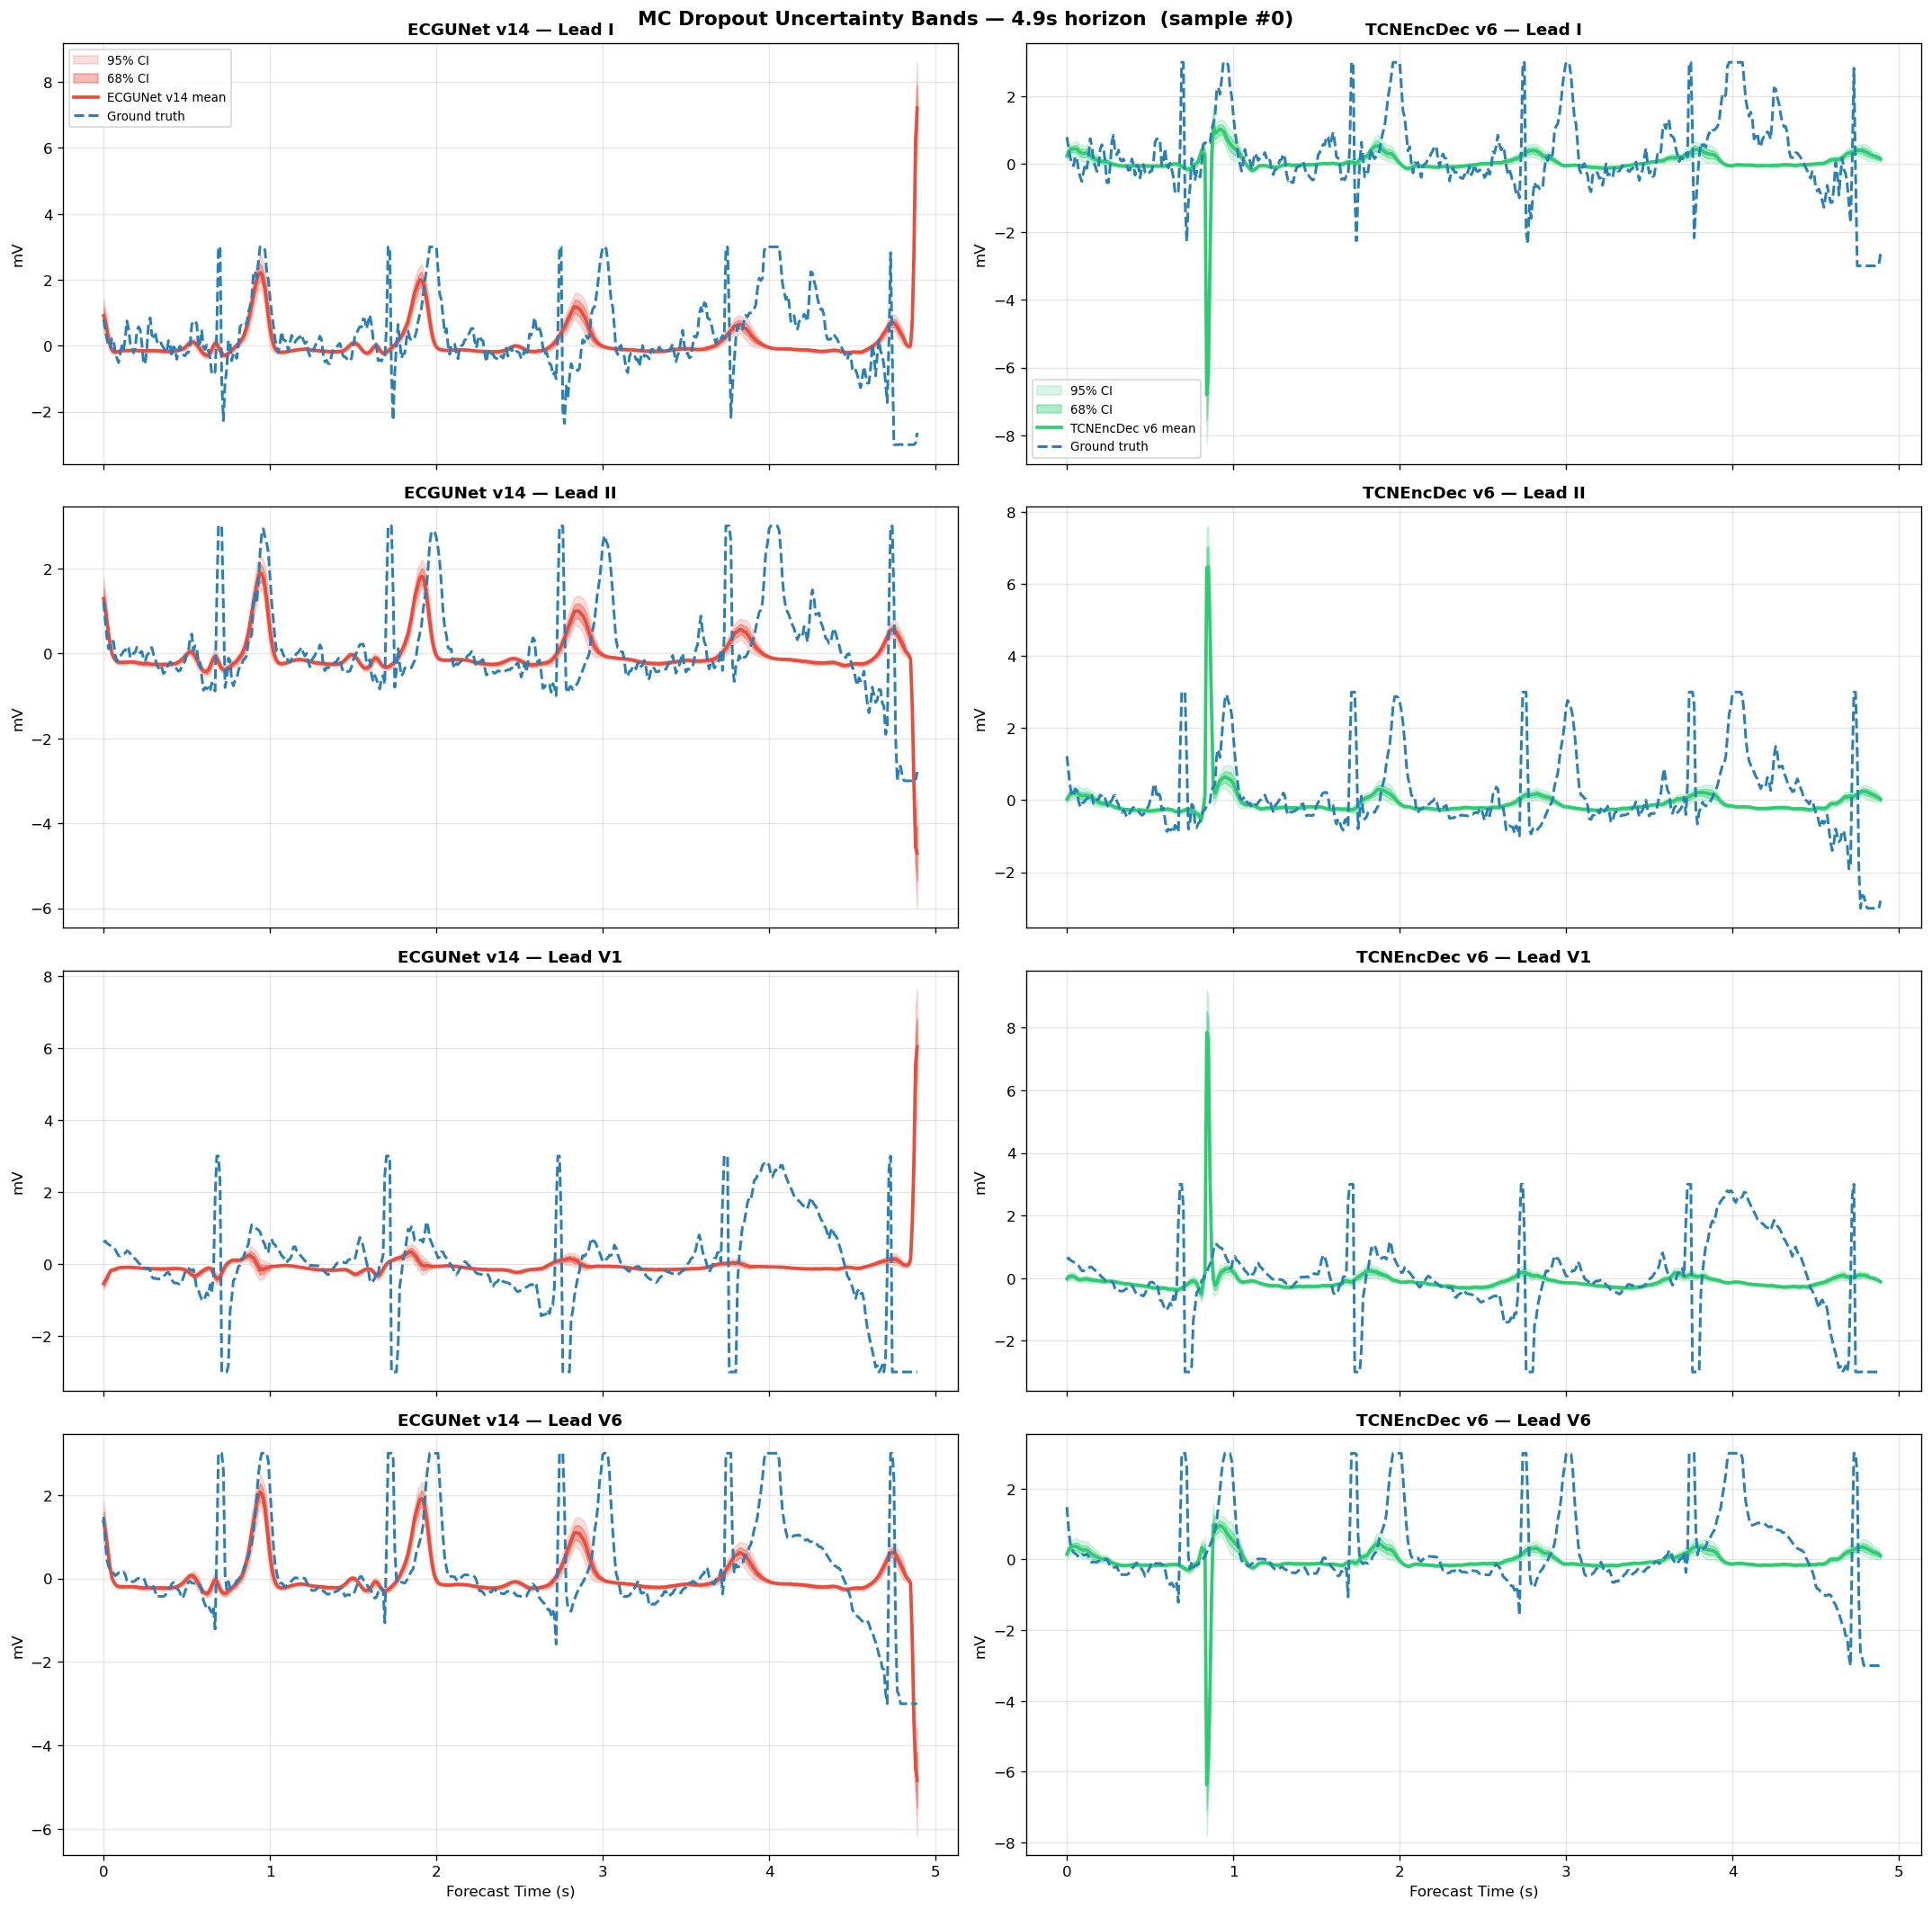

✅ 01_uncertainty_bands.png saved


In [7]:
# CELL 7 — UNCERTAINTY BANDS (4 leads, sample 0)
SAMPLE = 0
LEADS  = [0, 1, 6, 11]   # I, II, V1, V6
t = np.arange(HORIZON) / FS

fig, axes = plt.subplots(len(LEADS), 2, figsize=(18, 4.5*len(LEADS)), sharex=True)
for row, li in enumerate(LEADS):
    for col, (name, mean, std, color) in enumerate([
        ('ECGUNet v14',        cnn_mean, cnn_std, '#e74c3c'),
        ('TCNEncDec v6',       tcn_mean, tcn_std, '#2ecc71'),
    ]):
        ax = axes[row, col]
        ym = mean[SAMPLE, :, li]; ys = std[SAMPLE, :, li]
        yt = y_uq[SAMPLE, :, li]
        ax.fill_between(t, ym-2*ys, ym+2*ys, alpha=0.18, color=color, label='95% CI')
        ax.fill_between(t, ym-ys,   ym+ys,   alpha=0.38, color=color, label='68% CI')
        ax.plot(t, ym, color=color,     lw=2.2, label=f'{name} mean')
        ax.plot(t, yt, color='#2980b9', lw=1.8, label='Ground truth', ls='--')
        ax.set_title(f'{name} — Lead {LEAD_NAMES[li]}', fontweight='bold', fontsize=11)
        ax.set_ylabel('mV'); ax.grid(alpha=0.3)
        if row == 0: ax.legend(fontsize=8)

axes[-1, 0].set_xlabel('Forecast Time (s)'); axes[-1, 1].set_xlabel('Forecast Time (s)')
fig.suptitle(f'MC Dropout Uncertainty Bands — {HORIZON/FS:.1f}s horizon  (sample #{SAMPLE})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_uncertainty_bands.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 01_uncertainty_bands.png saved")


Model                  Epistemic (σ)   Aleatoric (MAE)
ECGUNet v14                  0.06165           0.74875
TCNEncDec v6                 0.08182           0.76531


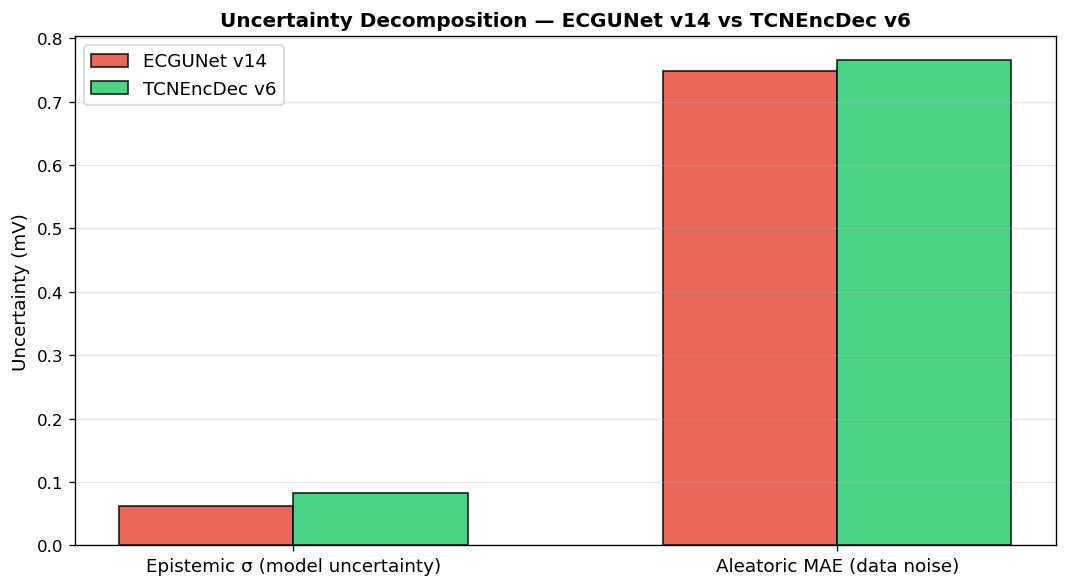

✅ 02_uncertainty_decomposition.png saved


In [8]:
# CELL 8 — EPISTEMIC vs ALEATORIC DECOMPOSITION
# Epistemic = MC Dropout std  (model uncertainty, reducible)
# Aleatoric  = MAE of mean prediction vs ground truth  (data noise, irreducible)

cnn_ep = float(cnn_std.mean())
cnn_al = float(np.abs(cnn_mean - y_uq).mean())
tcn_ep = float(tcn_std.mean())
tcn_al = float(np.abs(tcn_mean - y_uq).mean())

print(f"{'Model':20s}  {'Epistemic (σ)':>14s}  {'Aleatoric (MAE)':>16s}")
print(f"{'ECGUNet v14':20s}  {cnn_ep:>14.5f}  {cnn_al:>16.5f}")
print(f"{'TCNEncDec v6':20s}  {tcn_ep:>14.5f}  {tcn_al:>16.5f}")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2); w = 0.32
ax.bar(x-w/2, [cnn_ep, cnn_al], w, label='ECGUNet v14', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.bar(x+w/2, [tcn_ep, tcn_al], w, label='TCNEncDec v6',color='#2ecc71', alpha=0.85, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Epistemic σ (model uncertainty)', 'Aleatoric MAE (data noise)'], fontsize=11)
ax.set_ylabel('Uncertainty (mV)', fontsize=11)
ax.set_title('Uncertainty Decomposition — ECGUNet v14 vs TCNEncDec v6', fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_uncertainty_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 02_uncertainty_decomposition.png saved")


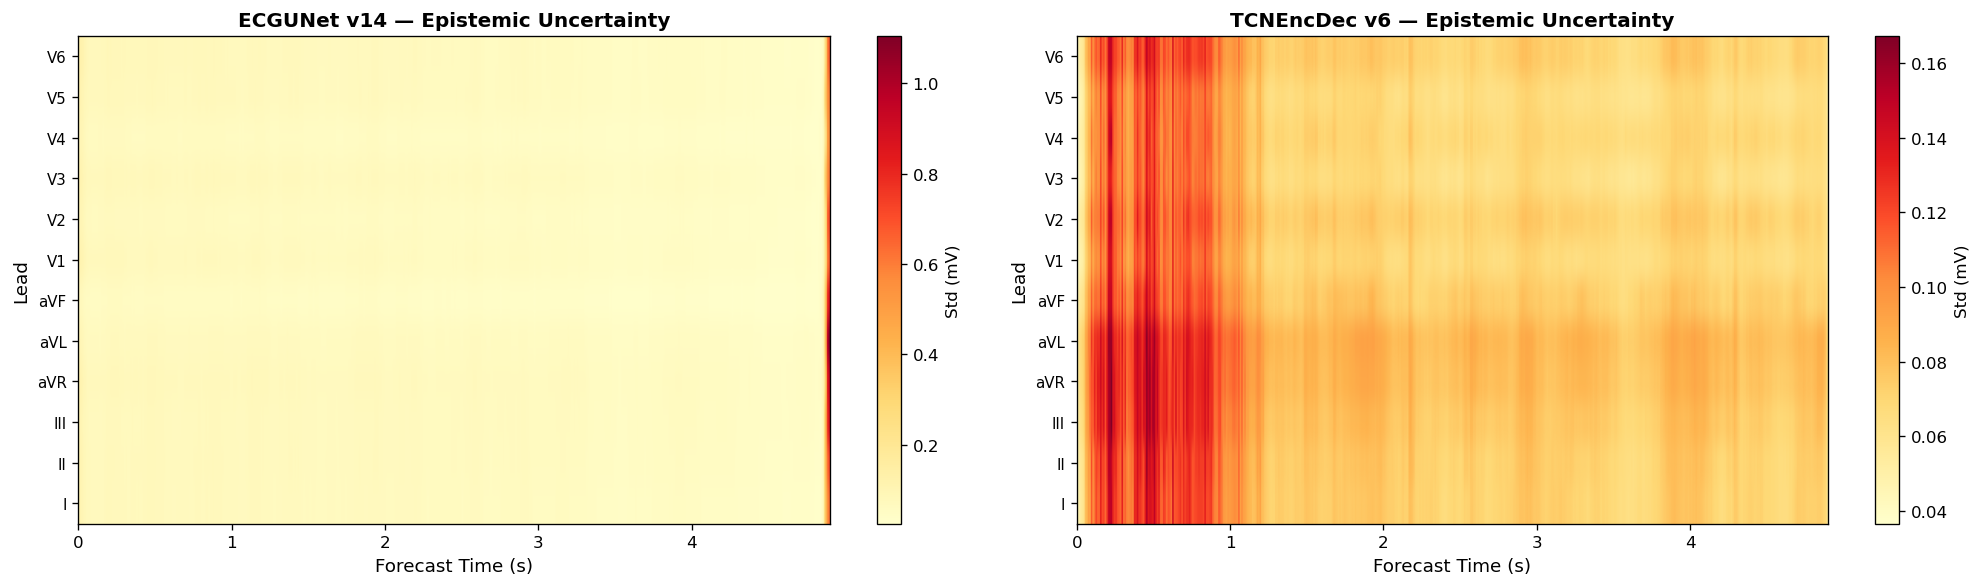

✅ 03_uncertainty_heatmap.png saved


In [9]:
# CELL 9 — EPISTEMIC UNCERTAINTY HEATMAP  (Lead × Forecast-Time)
cnn_hm = cnn_std.mean(0)   # (HORIZON, 12)
tcn_hm = tcn_std.mean(0)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
for ax, data, title in [
    (axes[0], cnn_hm, 'ECGUNet v14 — Epistemic Uncertainty'),
    (axes[1], tcn_hm, 'TCNEncDec v6 — Epistemic Uncertainty'),
]:
    im = ax.imshow(data.T, aspect='auto', cmap='YlOrRd',
                   extent=[0, HORIZON/FS, -0.5, N_LEADS-0.5])
    ax.set_xlabel('Forecast Time (s)', fontsize=11)
    ax.set_ylabel('Lead', fontsize=11)
    ax.set_yticks(range(N_LEADS))
    ax.set_yticklabels(LEAD_NAMES, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    plt.colorbar(im, ax=ax, label='Std (mV)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_uncertainty_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 03_uncertainty_heatmap.png saved")


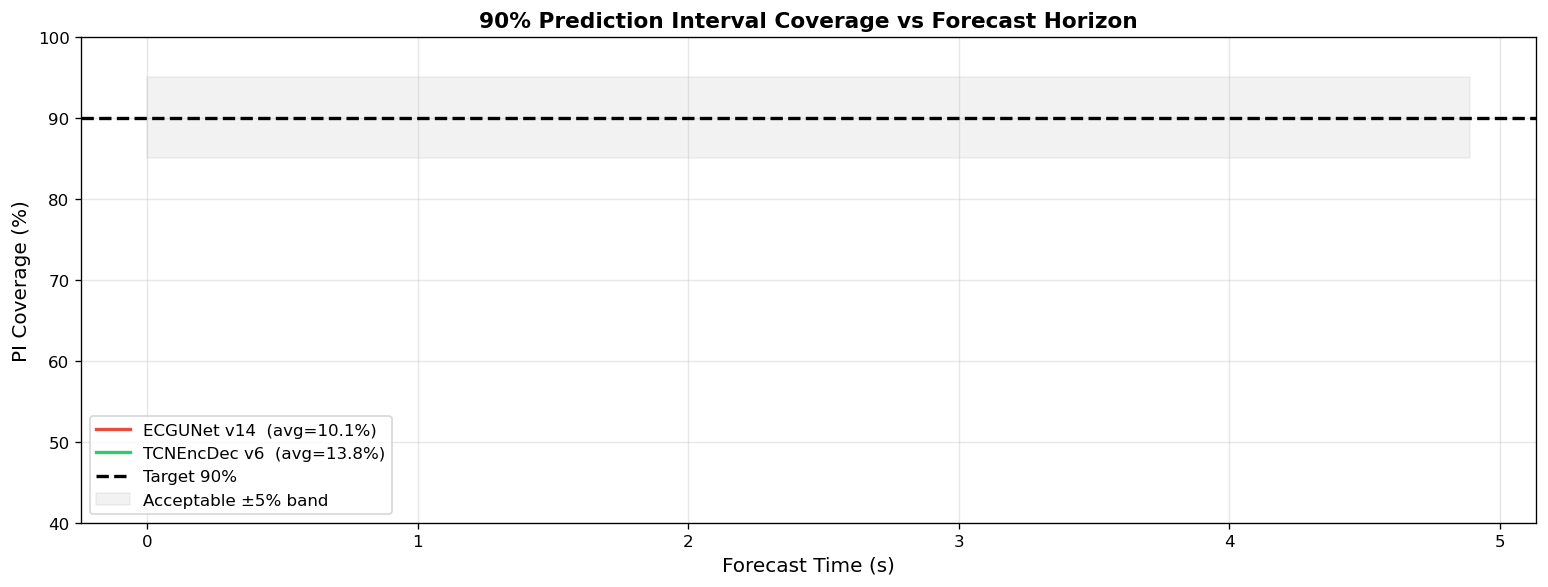

✅ 04_pi_coverage.png saved


In [10]:
# CELL 10 — 90% PREDICTION INTERVAL COVERAGE OVER TIME
t_fc = np.arange(HORIZON) / FS

fig, ax = plt.subplots(figsize=(13, 5))
for name, mean, std, color in [
    ('ECGUNet v14',  cnn_mean, cnn_std, '#e74c3c'),
    ('TCNEncDec v6', tcn_mean, tcn_std, '#2ecc71'),
]:
    lower = mean - 1.645 * std
    upper = mean + 1.645 * std
    cov   = ((y_uq >= lower) & (y_uq <= upper)).mean(axis=(0, 2)) * 100   # per time step
    ax.plot(t_fc, cov, lw=2, color=color, label=f'{name}  (avg={cov.mean():.1f}%)')

ax.axhline(90, color='black', ls='--', lw=2, label='Target 90%')
ax.fill_between(t_fc, 85, 95, alpha=0.10, color='grey', label='Acceptable ±5% band')
ax.set_ylim(40, 100)
ax.set_xlabel('Forecast Time (s)', fontsize=12)
ax.set_ylabel('PI Coverage (%)', fontsize=12)
ax.set_title('90% Prediction Interval Coverage vs Forecast Horizon', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_pi_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 04_pi_coverage.png saved")


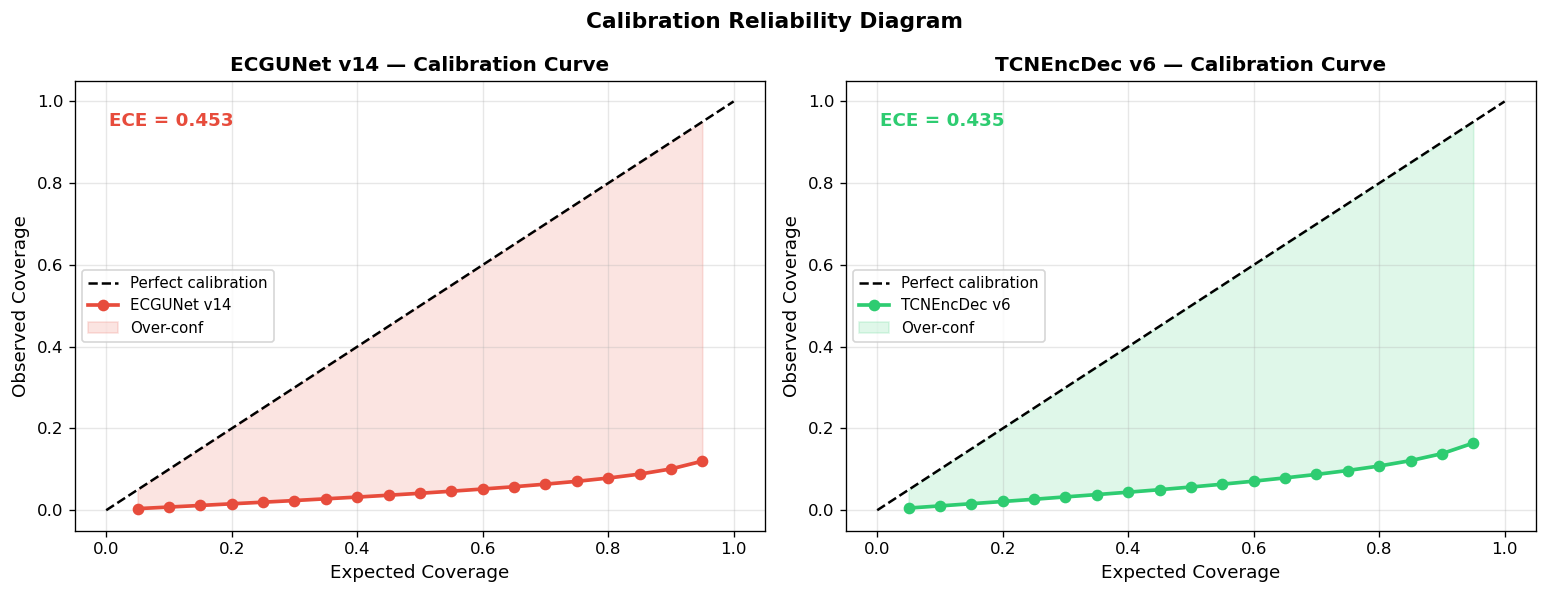

✅ 05_calibration_curve.png saved


In [11]:
# CELL 11 — CALIBRATION CURVE  (reliability diagram, lead-averaged)
from scipy.stats import norm as _norm

quantiles = np.linspace(0.05, 0.95, 19)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, mean, std, color in [
    (axes[0], 'ECGUNet v14',  cnn_mean, cnn_std, '#e74c3c'),
    (axes[1], 'TCNEncDec v6', tcn_mean, tcn_std, '#2ecc71'),
]:
    obs_coverage = []
    for q in quantiles:
        z = _norm.ppf((1 + q) / 2)
        in_pi = ((y_uq >= mean - z*std) & (y_uq <= mean + z*std)).mean()
        obs_coverage.append(float(in_pi))

    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect calibration')
    ax.plot(quantiles, obs_coverage, 'o-', color=color, lw=2.2, label=name)
    ax.fill_between(quantiles, quantiles, obs_coverage,
                    alpha=0.15, color=color,
                    label='Over-conf' if np.array(obs_coverage).mean() < np.array(quantiles).mean() else 'Under-conf')
    ax.set_xlabel('Expected Coverage', fontsize=11)
    ax.set_ylabel('Observed Coverage', fontsize=11)
    ax.set_title(f'{name} — Calibration Curve', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ece = float(np.abs(np.array(obs_coverage) - quantiles).mean())
    ax.text(0.05, 0.90, f'ECE = {ece:.3f}', transform=ax.transAxes,
            fontsize=11, color=color, fontweight='bold')

plt.suptitle('Calibration Reliability Diagram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_calibration_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 05_calibration_curve.png saved")


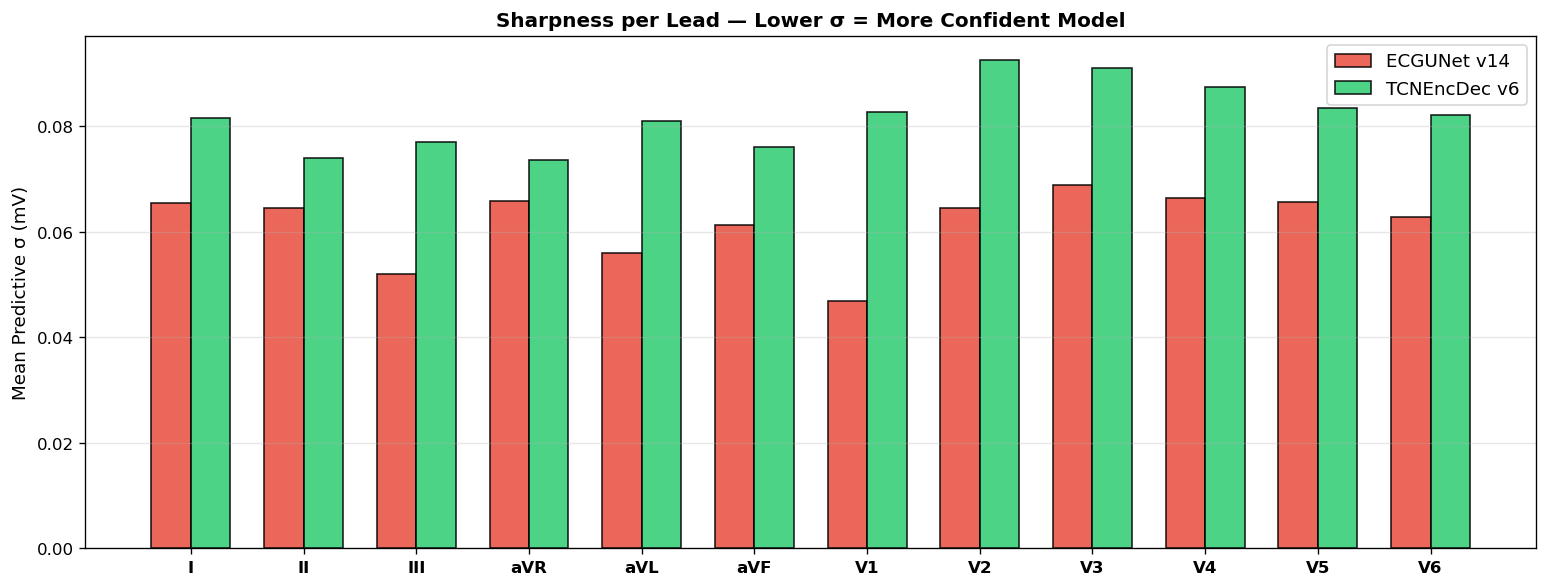

✅ 06_sharpness_per_lead.png saved


In [12]:
# CELL 12 — PER-LEAD SHARPNESS (mean predictive std)
cnn_sharp = cnn_std.mean(axis=(0,1))   # (12,)
tcn_sharp = tcn_std.mean(axis=(0,1))

x = np.arange(N_LEADS); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w/2, cnn_sharp, w, label='ECGUNet v14',  color='#e74c3c', alpha=0.85, edgecolor='black')
ax.bar(x+w/2, tcn_sharp, w, label='TCNEncDec v6', color='#2ecc71', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Predictive σ (mV)', fontsize=11)
ax.set_title('Sharpness per Lead — Lower σ = More Confident Model', fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_sharpness_per_lead.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 06_sharpness_per_lead.png saved")


In [13]:
# CELL 13 — SAVE MC RESULTS FOR DOWNSTREAM USE (explainability, etc.)
import pickle as _pkl

uq_results = {
    'cnn_mean': cnn_mean, 'cnn_std': cnn_std,
    'tcn_mean': tcn_mean, 'tcn_std': tcn_std,
    'y_uq': y_uq, 'X_uq': X_uq,
    'N_ITER': N_ITER, 'N_UQ': N_UQ,
    'FS': FS, 'HORIZON': HORIZON, 'N_LEADS': N_LEADS, 'LEAD_NAMES': LEAD_NAMES,
}
save_path = os.path.join(CKPT_DIR, 'uq_results.pkl')
with open(save_path, 'wb') as f:
    _pkl.dump(uq_results, f)

print(f"✅ MC results saved → {save_path}")
print("   Keys:", list(uq_results.keys()))


✅ MC results saved → ../reports/checkpoints/uq_results.pkl
   Keys: ['cnn_mean', 'cnn_std', 'tcn_mean', 'tcn_std', 'y_uq', 'X_uq', 'N_ITER', 'N_UQ', 'FS', 'HORIZON', 'N_LEADS', 'LEAD_NAMES']


In [14]:
# CELL 14 — SUMMARY TABLE
from IPython.display import display
import pandas as pd

cnn_rmse = float(np.sqrt(((cnn_mean - y_uq)**2).mean()))
tcn_rmse = float(np.sqrt(((tcn_mean - y_uq)**2).mean()))
cnn_mae  = float(np.abs(cnn_mean - y_uq).mean())
tcn_mae  = float(np.abs(tcn_mean - y_uq).mean())

# 90% PI coverage
def pi_cov(mean, std, y, z=1.645):
    return float(((y >= mean-z*std) & (y <= mean+z*std)).mean()) * 100

cnn_cov = pi_cov(cnn_mean, cnn_std, y_uq)
tcn_cov = pi_cov(tcn_mean, tcn_std, y_uq)

df = pd.DataFrame({
    'Model':        ['ECGUNet v14 (CNN-BiLSTM U-Net)', 'TCNEncDec v6'],
    'RMSE (mV)':    [f'{cnn_rmse:.5f}', f'{tcn_rmse:.5f}'],
    'MAE (mV)':     [f'{cnn_mae:.5f}',  f'{tcn_mae:.5f}'],
    'Epistemic σ':  [f'{cnn_ep:.5f}',   f'{tcn_ep:.5f}'],
    'Aleatoric MAE':[f'{cnn_al:.5f}',   f'{tcn_al:.5f}'],
    '90% PI Cov':   [f'{cnn_cov:.1f}%', f'{tcn_cov:.1f}%'],
})
display(df)
print("\n✅ UQ Notebook v2 complete — all figures in", FIG_DIR)


,Model,RMSE (mV),MAE (mV),Epistemic σ,Aleatoric MAE,90% PI Cov
0,ECGUNet v14 (CNN-BiLSTM U-Net),1.15639,0.74875,0.06165,0.74875,10.1%
1,TCNEncDec v6,1.21121,0.76531,0.08182,0.76531,13.8%



✅ UQ Notebook v2 complete — all figures in ../reports/figures/uncertainty
